In [1]:
#import packages
import numpy as np
from scipy.optimize import minimize
import weighted_maxcut_qaoa as qaoa #this is a .py file with my qaoa code
from qiskit.visualization import plot_histogram
import networkx as nx
from time import time
from matplotlib import pyplot as plt
plt.style.use('seaborn')

# Weighted Max-Cut

#### Application: Clustering within Autonomous Sensor Data

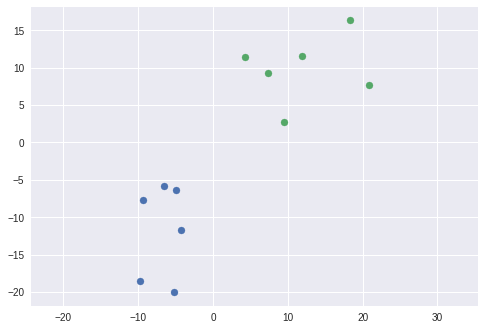

In [2]:
# set up two random distributions with n_points total points and plot
n1 = 6
n2 = 6
n_points = n1 + n2
set1  = np.random.normal(-10, 5, (2, n1))
set2 = np.random.normal(10, 5, (2, n2))
plt.scatter(set1[0, :], set1[1, :])
plt.scatter(set2[0, :], set2[1, :])
plt.axis('equal')
plt.show()     

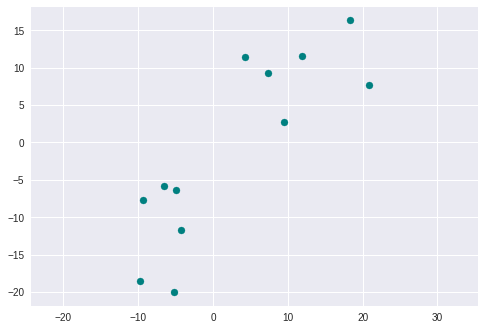

In [3]:
# create a dictionary mapping points to nodes
combined_set = np.hstack((set1, set2))
ind = np.arange(n_points)
np.random.shuffle(ind)
combined_set = combined_set[:, ind]
nodes_points = dict()
counter = 0
for column in range(combined_set.shape[1]):
    nodes_points[counter] = combined_set[:, column]
    counter += 1
nodes = nodes_points.keys()
plt.scatter(combined_set[0, :], combined_set[1, :], color='teal')
plt.axis('equal')
plt.show()

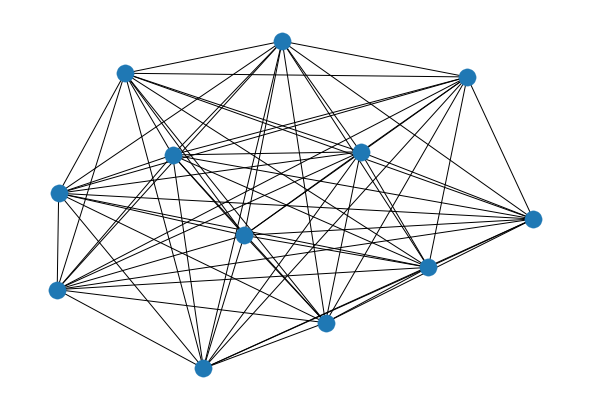

In [4]:
# now set up edges with weights corresponding to distances between nodes/points
G = nx.Graph()
for node1 in nodes:
    point1 = nodes_points[node1]
    for node2 in nodes:
        if node2 == node1:
            continue
        point2 = nodes_points[node2]
        weight = np.linalg.norm(point1 - point2)
        G.add_edge(node1, node2, weight=weight)

# draw the graph (note that weight is not reflected here as of now, gets messy)
nx.draw(G)

In [5]:
# get the expectation function from qaoa.py
start = time()
n_layers = n_points #number of layers (scale it up linearly with n_points)
shots = 2**10
expectation = qaoa.get_expectation(G, n_layers, shots=shots)

# minimize the expectation by running the circuit
req = {'type':'ineq', 'fun':lambda x:x} #this forces the params to be nonnegative
counter = 0
while True: #keep going until we get an accurate result 
    initial_params = .01*np.random.rand(2*n_layers)
    sol = minimize(expectation, initial_params, method='COBYLA', constraints=req)
    counts = expectation(sol.x, return_counts=True)[1]
    sorted_counts = np.sort(list(counts.values()))[::-1]
    max_val = sorted_counts[0]
    remaining_avg = np.mean(sorted_counts[2:6])
    diff_ratio = (max_val - remaining_avg)/shots #relative distance between first 2 and next highest counts
    if diff_ratio > .005: #min accepted difference ratio (a bit arbitrary, works well empirically)
        break
    counter += 1
    if counter >= 10: #call it after 10 tries
        raise Exception('Low Accuracy!')
    print('Low accuracy (Diff Ratio ' + str(diff_ratio) + '). Trying again with new parameters.')
print(sol)

# get the optimal bitstring we found and print it, along with other stats
true1 = ['0' for x in range(n1)]
true2 = ['1' for x in range(n2)]
true_bitstring = ''.join(np.concatenate((true1, true2))[ind])
found_bitstring = list(counts.keys())[np.argmax(list(counts.values()))]
print('\nTrue Optimal Bitstring: ' + true_bitstring)
print('Found Bitstring: ' + found_bitstring)
print('Difference Ratio: ' + str(diff_ratio))
print('Runtime: ' + str(round(time() - start, 2)) + ' seconds')

     fun: -940.5436525956595
   maxcv: 0.0
 message: 'Optimization terminated successfully.'
    nfev: 317
  status: 1
 success: True
       x: array([9.93114901e-01, 1.00199564e+00, 2.45406605e-02, 9.94606780e-01,
       2.59874931e-01, 9.97159728e-01, 1.17236273e-03, 1.99181581e-02,
       2.51118320e-02, 5.11516134e-03, 1.02422556e+00, 2.24347192e-02,
       3.94313420e-03, 1.38275613e-02, 9.40150553e-04, 9.08363079e-03,
       1.23588116e-02, 2.40561120e-03, 8.81296961e-04, 1.20116038e-03,
       1.64234204e-03, 1.06619315e-02, 8.91806620e-04, 9.79683711e-01])

True Optimal Bitstring: 001101101100
Found Bitstring: 110010010011
Difference Ratio: 0.2255859375
Runtime: 47.49 seconds


In [6]:
# plot a histogram of the bitstring counts using our optimized parameters
# plot_histogram(counts)

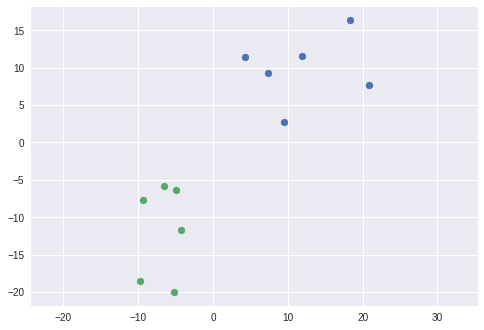

In [7]:
# convert the result back to points separated by the cut we found above
cluster0, cluster1 = [], []
counter = 0
for char in found_bitstring:
    if int(char) == 0:
        cluster0.append(nodes_points[counter])
    else:
        cluster1.append(nodes_points[counter])
    counter += 1

# plot our points/clusters
cluster0 = np.vstack((cluster0)).T
plt.scatter(cluster0[0, :], cluster0[1, :])
cluster1 = np.vstack((cluster1)).T
plt.scatter(cluster1[0, :], cluster1[1, :])
plt.axis('equal')
plt.show()

In [8]:
qaoa.maxcut_obj(true_bitstring, G), qaoa.maxcut_obj(found_bitstring, G), true_bitstring, found_bitstring

(-1050.8605711925964, -1050.8605711925964, '001101101100', '110010010011')

# TODO: Change cost function (and thus the circuit too) so that it no longer favors more cuts than necessary